# COE 311K Final Project - Part 3 of 3 by Vishnu Prasad (vp9439)

## Section 1: Review of Part 2

From part 2, we chose to solve a highly damped mechanical system in the form of an overdamped spring-mass system by modeling it as a stiff first-order differential equation. 

This is the governing ODE:

## $\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$

Substituting parameters from part 2, we can rewrite the ODE as:

## $\frac{dx}{dt} = -5000x + 0.002sin(t)$

In part 2, we implemented a basic implicit solver using Backward Euler's Method with Newton-Raphson iteration to solve this stiff equation. This method evaluates $x_{n+1}$ by using $f(t_{n+1}, x_{n+1})$, creating a residual function $g(x_{n+1})$ that is solved at each time step using Newton-Raphson iteration.

The stiffness parameter was calculated in the previous part by evaluating the ratio of fastest to slowest time scales which came out to be 5000, which is indicative of a system that includes both fast and slow dynamics, a key characteristic of stiff systems. Stiff systems require extremely small step sizes for explicit methods to converge, which is why we used implicit methods in part 2 to expand stability constraints to more reasonable step size magnitudes.

## Section 2: Newton-Raphson Damping Implementation

Newton-Raphson iteration can be prone to failure if convergence is difficult such as when the initial guess is poor, the step size is too large, or the residual function is nonlinear. 

In these scenarios, we can implement a damping factor α ∈ (0,1] such that:

## $y^{(k+1)} = y^{(k)} - α\frac{g(y^(k))}{g'(y^(k))}$

The damping factor dynamically allows Newton-Raphson to take smaller steps and avoid failure. At each step, we calculate α using a line search algorithm which starts with α = 1 and iteratively reduces itself to ensure that the residual decreases. This method improves Newton-Raphson convergence by preventing itself from overshooting the solution with larger step sizes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return -5000*x + 0.002*np.sin(t)

def g_func(x_next, x_prev, t_next, h):
    return x_next - x_prev - h * f(t_next, x_next)

def g_prime_func(h):
    return 1 + h*5000

# Newton-Raphson function
def basic_newton_raphson(x_n, t_next, h, g_func, g_prime_func, tol=1e-6, max_iter=20):
    # Initial guess
    x = x_n
    dg = g_prime_func(h)
    
    # Newton-Raphson loop
    for i in range(max_iter):
        g = g_func(x, x_n, t_next, h)
        
        # Compute next iteration
        x_new = x - g / dg
        
        # Check for convergence
        if abs(x_new - x) < tol:
            return x_new, i + 1, True
        
        # Update x
        x = x_new

    return None, max_iter, False

# Adaptive Backward Euler
def damped_newton_raphson(x_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    x_guess = x_n
    
    for k in range(max_iter):
        g = g_func(x_guess, x_n, t_next, h)
        
        if abs(g) < tol:
            return x_guess, k, True
        
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            x_new = x_guess + alpha * delta
            g_new = abs(g_func(x_new, x_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return x_guess, k, False
        
        x_guess = x_new
    
    return x_guess, max_iter, False

# Problem where undamped NR fails
h_large = 2  # Very large step size
x_prev = 1.0
t_prev = 0.0
t_next = t_prev + h_large

print("Testing undamped NR with h = 2.0:")
x_undamped, iters, success = basic_newton_raphson(x_prev, t_next, h_large, g_func, g_prime_func)
print(f"Converged: {success}, iterations: {iters}")

print("\nTesting damped NR with h = 2.0:")
x_damped, iters, success = damped_newton_raphson(x_prev, t_next, h_large, g_func, g_prime_func)
print(f"Converged: {success}, iterations: {iters}")

Testing undamped NR with h = 2.0:
Converged: True, iterations: 2

Testing damped NR with h = 2.0:
Converged: True, iterations: 1


Since this particular ODE is linear, both the undamped Newton-Raphson and the damped Newton-Rapshon algorithms converged in under 2 iterations regardless of how large we set the initial step size. Therefore, implementing the damped Newton-Raphson method did not significantly improve the performance in this case. However, in general, damping does improve algorithm robustness compared to the basic method when solving nonlinear systems with a very large initial step size because damped NR is able to take smaller steps when necessary to reduce iteration count.

## Section 3: Adaptive Step Size Implementation

In [2]:
def f(t, x):
    return -5000*x + 0.002*np.sin(t)

def g_func(x_next, x_prev, t_next, h):
    return x_next - x_prev - h * f(t_next, x_next)

def g_prime_func(h):
    return 1 + h*5000

def euler_backward_fixed(f, x0, t0, tf, h):
    # Create arrays to store t, x, and iteration count
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros_like(t_values)
    iter_values = np.zeros_like(t_values)
    
    # Set initial conditions
    x_values[0] = x0
    iter_values[0] = 0
    
    # Backward Euler loop
    for i in range(1, len(t_values)):
        # Current values
        t_next = t_values[i]
        x_prev = x_values[i - 1]
        
        # Define g and dg for Newton-Raphson
        g = lambda x_next: x_next - x_prev - h * f(t_next, x_next)
        dg = lambda x_next: 1 + 5000*h
        
        x_guess = x_prev + h * f(t_values[i-1], x_prev) # Initial guess using explicit Euler predictor
        x_next, iterations = nr_solver(x_prev, t_values[i], h) # Solve x_(n+1) through NR
        
        # Error handling
        if x_next is None:
            raise RuntimeError(f"Newton failed at step {i}")
        
        # Store x and iteration count
        x_values[i] = x_next
        iter_values[i] = iterations
        
    return t_values, x_values

def nr_solver(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k
        
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k
        
        y_guess = y_new
    
    return y_guess, max_iter

def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    """
    Estimate error using step-doubling (Richardson extrapolation)
    
    1. Take ONE step of size h
    2. Take TWO steps of size h/2
    3. Compare the results
    
    Parameters:
    - y_n: current solution value
    - t_n: current time
    - h: step size to try
    - nr_solver: function that takes one implicit Euler step
    
    Returns:
    - y_full: result from single step (less accurate)
    - y_half: result from two half-steps (more accurate)
    - error: estimated local error
    """
    # Single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)
    
    # Two half-steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2, h/2)
    y_half, iters_2 = nr_solver(y_half_1, t_n + h, h/2)
    
    # Error estimate
    error = abs(y_half - y_full)
    
    # Total NR iterations for this error estimate
    total_iters = iters_full + iters_1 + iters_2
    
    return y_full, y_half, error, total_iters


def adaptive_step(y_n, t_n, h, tol, nr_solver, 
                  h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control
    
    Returns:
    - y_next: accepted solution value
    - h_used: step size that was accepted
    - h_new: suggested step size for next step
    - accepted: True if step was accepted
    - iters: total NR iterations used
    """
    # Try the step with error estimation
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )
    
    # Compute new step size suggestion
    if error < 1e-14:  # Error very small
        h_new = min(2.0 * h, h_max)
    else:
        # Standard formula: h_new = h * sqrt(tol/err)
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new  # Safety factor
        h_new = max(h_min, min(h_max, h_new))
    
    # Also don't let h change too dramatically
    h_new = max(0.2 * h, min(5.0 * h, h_new))
    
    # Accept or reject?
    if error < tol:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters, error
    else:
        # REJECT: don't update y, suggest smaller h
        return y_n, h, h_new, False, iters, error

def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol, h_min=1e-6, h_max=1.0,nr_tol=1e-8, max_nr_iter=20):
    """
    Adaptive Euler's Backward with damped Newton-Raphson
    
    Parameters:
    - f: ODE function
    - y0: initial condition
    - t0, t_final: time span
    - h0: initial step size
    - tol: error tolerance
    - h_min, h_max: step size bounds
    - nr_tol: Newton-Raphson tolerance
    - max_nr_iter: max NR iterations
    
    Returns:
    - t: time points (non-uniform!)
    - y: solution values
    - h_history: step sizes used
    - stats: dictionary with performance statistics
    """
    
    # Initialize
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations_per_step': [],
        'total_nr_iterations': 0
    }
    
    # Main loop
    while t[-1] < t_final:
        y_n = y[-1]
        t_n = t[-1]

        step_accepted = False

        while not step_accepted:
            y_next, h_used, h_new, accepted, iters, error = adaptive_step(y_n, t_n, h, tol, nr_solver)

            stats['nr_iterations_per_step'].append(iters)
            stats['total_nr_iterations'] += iters

            if accepted:
                # Accept step
                t.append(t_n + h_used)
                y.append(y_next)
                h_history.append(h_used)
                error_history.append(error)

                stats['accepted_steps'] += 1

                h = h_new
                step_accepted = True
            else:
                # Reject step
                stats['rejected_steps'] += 1
                h = h_new

            if h < h_min:
                raise RuntimeError("Step size too small")
    
    return np.array(t), np.array(y), h_history, error_history, stats

## Section 4: Performance Analysis


Equal Accuracy Comparison:
Method               Steps      NR Iterations   Max Error      
------------------------------------------------------------
Fixed (h=0.01)       301        903             1.96e-02       
Adaptive             119        377             2.25e-03       

Same Step Budget Comparison:
Method               Steps      Max Error      
--------------------------------------------------
Fixed (same budget)  120        7.87e-03       
Adaptive             119        2.25e-03       


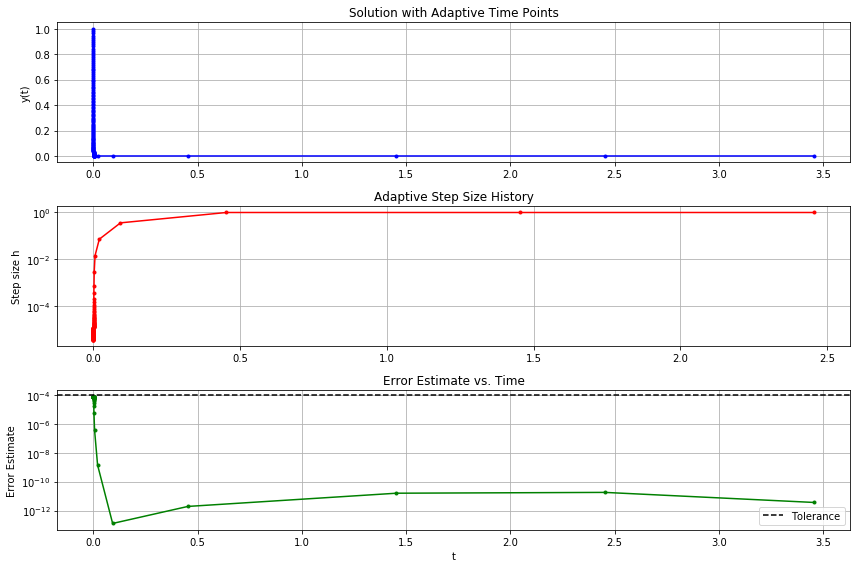

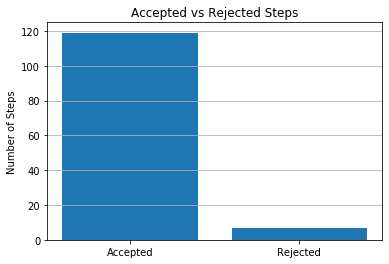

In [3]:
def y_exact(t):
    denom = 5000**2 + 1
    A = 0.002 * 5000 / denom
    B = -0.002 / denom
    C = 1 - B   # enforce x(0) = 1

    return C * np.exp(-5000*t) + A * np.sin(t) + B * np.cos(t)

def performance_analysis(y0, t0, t_final, tol, h0):
    # Fixed step size (baseline)
    t_fixed, y_fixed = euler_backward_fixed(f, y0, t0, t_final, h=0.01)

    # Adaptive step size (same target accuracy)
    t_adapt, y_adapt, h_hist, error_history, stats = adaptive_implicit_euler(f, y0, t0, t_final, h0=h0, tol=tol)

    error_fixed = np.max(np.abs(y_fixed - y_exact(t_fixed)))
    error_adapt = np.max(np.abs(y_adapt - y_exact(t_adapt)))

    print("\nEqual Accuracy Comparison:")
    print(f"{'Method':<20} {'Steps':<10} {'NR Iterations':<15} {'Max Error':<15}")
    print("-" * 60)
    print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {len(t_fixed)*3:<15} {error_fixed:<15.2e}")
    print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['total_nr_iterations']:<15} {error_adapt:<15.2e}")

    # Same step budget comparison
    N_adapt = stats['accepted_steps']
    T = t_final - t0
    h_same = T / N_adapt

    t_fixed_budget, y_fixed_budget = euler_backward_fixed(f, y0, t0, t_final, h=h_same)
    error_fixed_budget = np.max(np.abs(y_fixed_budget - y_exact(t_fixed_budget)))
    error_adapt = np.max(np.abs(y_adapt - y_exact(t_adapt)))

    print("\nSame Step Budget Comparison:")
    print(f"{'Method':<20} {'Steps':<10} {'Max Error':<15}")
    print("-" * 50)
    print(f"{'Fixed (same budget)':<20} {len(t_fixed_budget):<10} {error_fixed_budget:<15.2e}")
    print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {error_adapt:<15.2e}")
    
    return t_adapt, y_adapt, h_hist, error_history, stats

# Parameters
y0 = 1.0
t0 = 0.0
t_final = 3.0
tol = 1e-4
h0 = 0.1

# Performance analysis tables (Equal Accuracy / Same step budget)
t_adapt, y_adapt, h_hist, error_history, stats = performance_analysis(y0, t0, t_final, tol, h0)

# Visualize how step size adapts
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)
# Plot error estimate
plt.semilogy(t_adapt[1:], error_history, 'g-o', markersize=3)
plt.axhline(y=tol, color='k', linestyle='--', label='Tolerance')
plt.ylabel('Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Accepted vs. Rejected Steps plot
plt.figure()

plt.bar(['Accepted', 'Rejected'], [stats['accepted_steps'], stats['rejected_steps']])

plt.title('Accepted vs Rejected Steps')
plt.ylabel('Number of Steps')
plt.grid(axis='y')

plt.show()

To measure the performance of the adaptive step size Backward Euler method, we compared it against the fixed-step size Backward Euler method created in part 2 to solve a stiff ODE. Both of these methods were compared with equal accuracy criteria to measure computational efficiency and equal step budget criteria to measure accuracy.

For equal accuracy, we set a target tolerance of $10^{-4}$. From the first comparison table, we can observe that the adaptive method required around 60% less steps and 58% less Newton-Raphson iterations to reach the target accuracy compared to the fixed method. Even while requiring significantly less computational power, the adaptive step size method achieved a lower maximum global error than the fixed step size method. To evaluate accuracy, both of the methods were compared under the same step budget as well. In about 120 steps in total for each algorithm, the adaptive method was able to produce a maximum global error 3x smaller than the fixed method. These results show that the adaptive step size method for Backward Euler's makes a more effective and accurate use of computational power compared to the fixed step size method.

Furthermore, we can gain a better understanding of how the adaptive method evolved throughout the time interval by looking at the step size history and accepted vs rejected steps plots. The step size history plot demonstrates how the adaptive method chooses to take smaller steps as it navigates through the fast transient of the solution to the stiff ODE, before taking larger step sizes as the solution becomes smoother. Additionally, the number of steps rejected by the adaptive method is relatively small, occurring during the fast transient, which confirms that minimal computational power is wasted on rejected steps. By dynamically adjusting step size over time, adaptive step size methods become particularly effective for stiff equations where extreme variation in solution behavior exists in different time intervals.

## Section 5: Robustness Testing

In [4]:
# Robustness test with large initial h
tol = 1e-4
h0_high = 1.0

print('ROBUSTNESS TEST WITH LARGE INITIAL STEP SIZE:')
t_adapt, y_adapt, h_hist, error_history, stats = performance_analysis(y0, t0, t_final, tol, h0_high)
print('\n')

print('ROBUSTNESS TEST WITH TIGHT TOLERANCE:')
# Robustness test with tight tolerance
tol_tight = 1e-5
h0 = 0.1

t_adapt, y_adapt, h_hist, error_history, stats = performance_analysis(y0, t0, t_final, tol_tight, h0)

ROBUSTNESS TEST WITH LARGE INITIAL STEP SIZE:

Equal Accuracy Comparison:
Method               Steps      NR Iterations   Max Error      
------------------------------------------------------------
Fixed (h=0.01)       301        903             1.96e-02       
Adaptive             119        386             2.25e-03       

Same Step Budget Comparison:
Method               Steps      Max Error      
--------------------------------------------------
Fixed (same budget)  120        7.87e-03       
Adaptive             119        2.25e-03       


ROBUSTNESS TEST WITH TIGHT TOLERANCE:

Equal Accuracy Comparison:
Method               Steps      NR Iterations   Max Error      
------------------------------------------------------------
Fixed (h=0.01)       301        903             1.96e-02       
Adaptive             359        1100            7.11e-04       

Same Step Budget Comparison:
Method               Steps      Max Error      
-------------------------------------------------

Even with a large initial step size, the adaptive method is still able to converge in about the same number of iterations as with a standard initial step size. This is due to the linearity of the stiff ODE provided from part 2, as Newton-Raphson will converge in only one iteration, regardless of how large the step size is.

When the tolerance was tightened for the adaptive solver, it required more iterations to meet the accuracy requirements, but its maximum error tended be much lower than the fixed method overall. These robustness tests showed how the adaptive method consistently delivered a high accuracy even with stricter limits and lower computational allocation.

## Section 6: Conclusions

Damping becomes necessary when a step of Backward Euler's Method is ill-conditioned for Newton-Raphson iteration, which makes standard processes diverge. In these cases, line search damping can ensure consistent reduction in the residual function, even when the initial guess is far from the real solution.

Adaptive step sizes are worth the algorithmic complexity when the solutions exhibits rapidly changing behavior, such as in stiff equations, where the fast transient term changes quickly before the solution smoothens out. In these situations, adaptive step size methods allow implicit methods to focus computational resources on areas of the solution where it is needed most, achieving a balance between accuracy and efficiency. One key lesson that I learned after completing this project is that the most effective numerical methods for solving an ODE often combine multiple strategies rather than relying on a single technique to account for solver robustness.